Fahad Hossain - fahadhossain0503@gmail.com

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

Solution of Q-1

In [130]:
df = pd.read_csv('titanic_data_updated.csv')

print(f'Shape of the dataset - {df.shape}')

print("............first 10 rows...........")
display(df.head(10))

print("............random 5 samples...........")
display(df.sample(5))

Shape of the dataset - (891, 12)
............first 10 rows...........


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


............random 5 samples...........


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
304,305,no,third,"Williams, Mr. Howard Hugh ""Harry""",male,NaN,0,0,A/5 2466,8.0500,NaN,S
119,120,no,third,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S
423,424,no,third,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",female,28.0,1,1,347080,14.4000,NaN,S
519,520,no,third,"Pavlovic, Mr. Stefo",male,32.0,0,0,349242,7.8958,NaN,S
794,795,no,third,"Dantcheff, Mr. Ristiu",male,25.0,0,0,349203,7.8958,NaN,S


Solution of Q-2

In [131]:
# Total missing values of the df
df.isnull().sum().sum()

df.duplicated().sum()
df.drop_duplicates(inplace=True)

Solution of Q-3

In [132]:
print(df.info())

df.describe()

# My observations
# 1. The dataset has total of 7 categorical columns and 5 numerical columns
# 2. Max aged peoples spending more money to buy ticket

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB
None


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Solution of Q-4

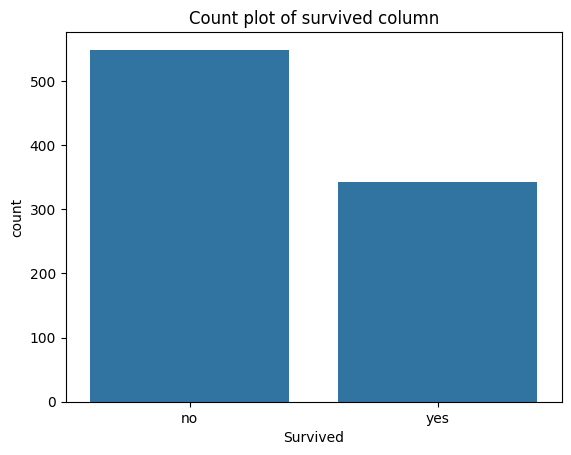

Percentage discribution


,count
Survived,
no,61.616162
yes,38.383838


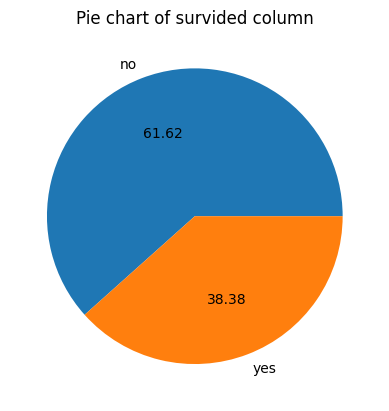

In [133]:
# Count plot of survived column
sns.countplot(data = df, x=df['Survived'])
plt.title('Count plot of survived column')
plt.show()

# percentage distribution
survived_rate = (df['Survived'].value_counts() / len(df['Survived'])) * 100
print("Percentage discribution")
display(survived_rate)

# pie chart
value_counts = df['Survived'].value_counts()
plt.pie(value_counts, labels=df['Survived'].unique(), autopct='%1.2f')
plt.title("Pie chart of survided column")
plt.show()

# Insights
# 1. Overall survived rate is almost 38 percent
# 2. Overall unsurvived rate is almost 62 percent

Solution of Q-5

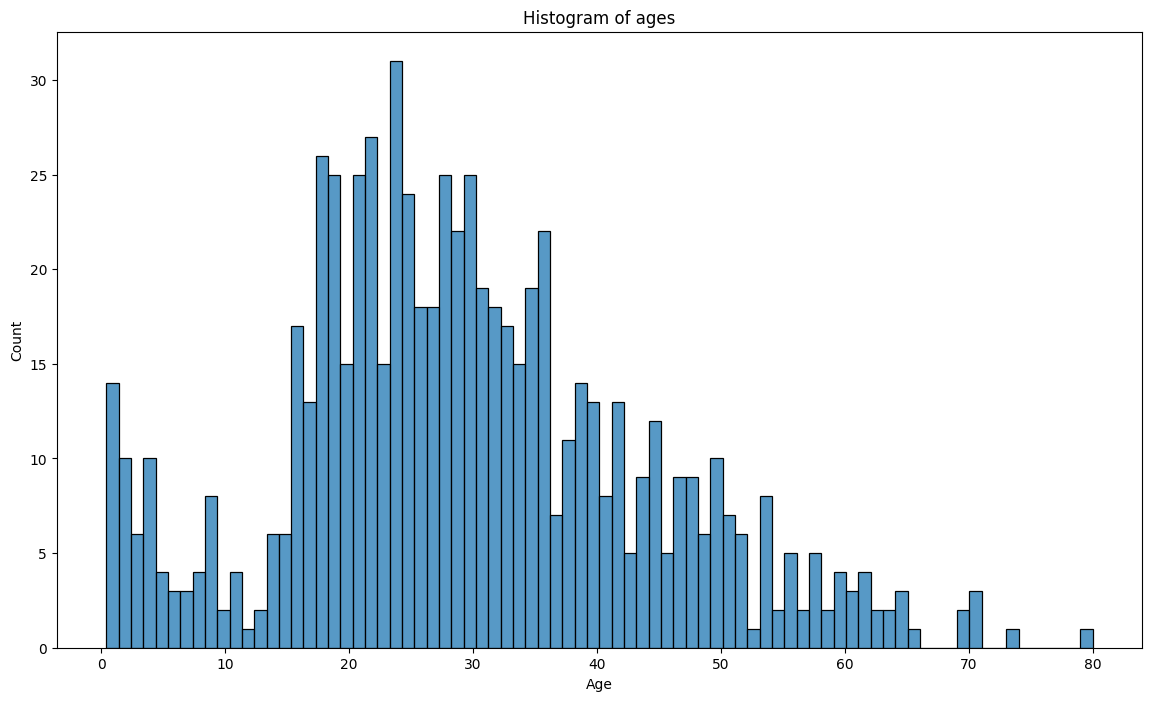

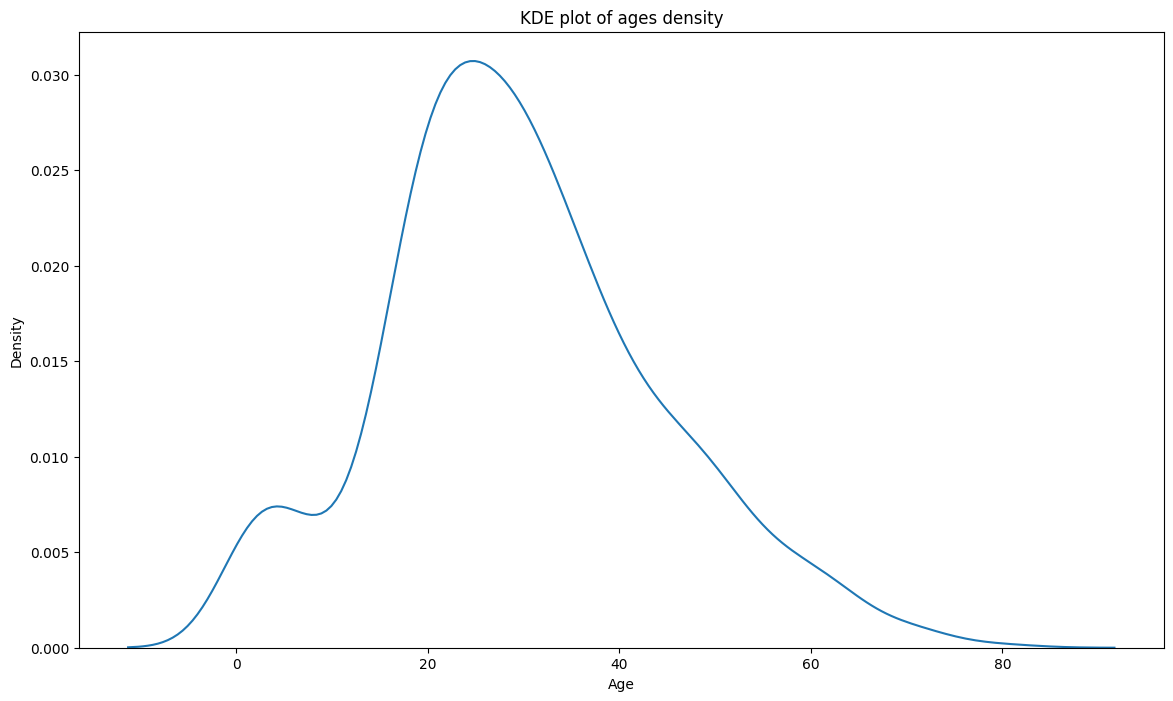

In [134]:
# df.head(3)
# histogram of age column
plt.figure(figsize=(14, 8))
sns.histplot(data=df['Age'], bins=80)
plt.title("Histogram of ages")
plt.show()

# KDE plot of age column
plt.figure(figsize=(14, 8))
sns.kdeplot(data=df['Age'])
plt.title("KDE plot of ages density")
plt.show()

# My Observations
# 1. Adults have a higher survival ratio than younger or older people.
# 2. The survival ratio of the youngest babies is also high.

Solution of Q-6

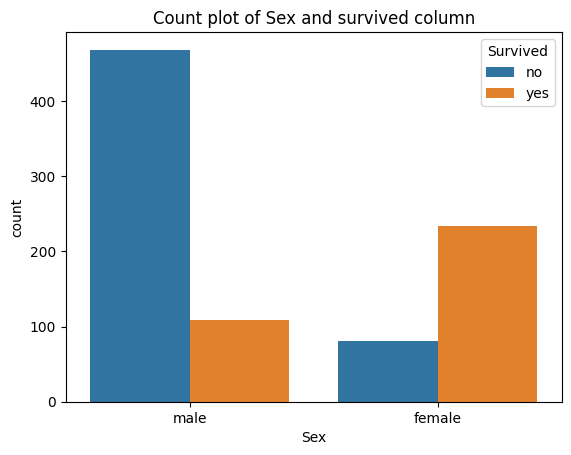

Normalized survival ratio of group by gender.............
Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


In [135]:
sns.countplot(x=df['Sex'], hue=df['Survived'])
plt.title('Count plot of Sex and survived column')
plt.show()

print("Normalized survival ratio of group by gender.............")
group_by_gender = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(group_by_gender)

# Insights
# 1. Man's count is more high than women
# 2. Women survival ratio is higher than man

Solution of Q-7

Text(0.5, 1.0, 'Barplot for showing relation between Pclass and Fare')

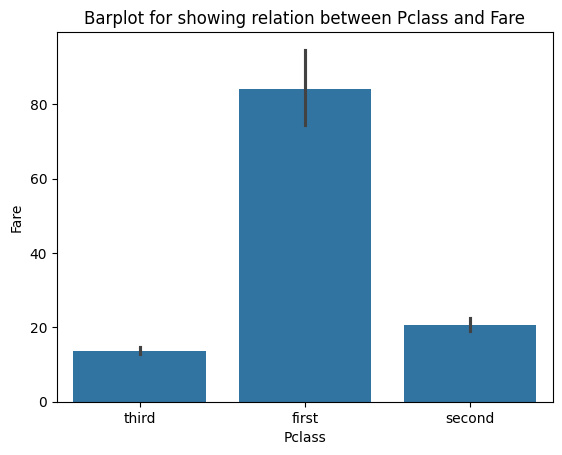

In [136]:
df.head(5)

sns.barplot(data=df, x='Pclass', y='Fare')
plt.title('Barplot for showing relation between Pclass and Fare')

# My Observation
# 1. First-class passenger count is high
# 2. There has someones who didn't paying the fare


Solution of Q-8

Text(0.5, 1.0, 'KDE plot for showing age density of survived and non-survived passengers')

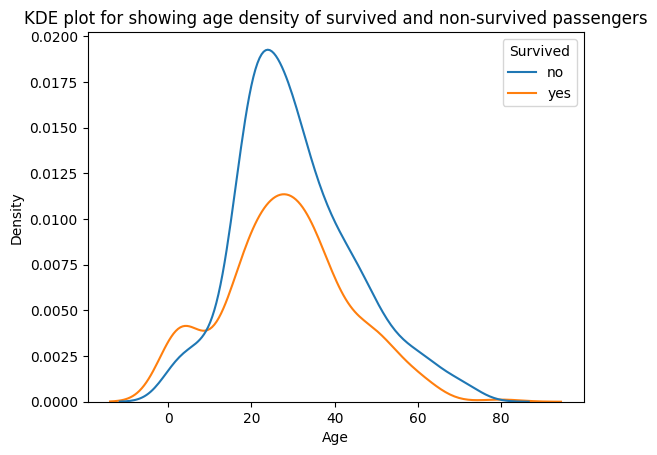

In [137]:
sns.kdeplot(data=df, x='Age', hue='Survived')
plt.title("KDE plot for showing age density of survived and non-survived passengers")

# My Observation
# 1. The lower aged peoples survival rate is high
# 2. Comparedly older peoples survival ratio is very low

Solution of Q-9

In [138]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [139]:
# Feature and Terget separation
x = df.drop(['Survived'], axis=1)
y = df['Survived']
# print(x)
# print(y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

display(x_train.shape, x_test.shape)
display(y_train.shape, y_test.shape)

(712, 8)

(179, 8)

(712,)

(179,)

Solution of Q-10

In [140]:
age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(x_train[['Age']])
x_train['Age'] = age_imputer.transform(x_train[['Age']]).ravel()
x_test['Age'] = age_imputer.transform(x_test[['Age']]).ravel()
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2


In [141]:
embark_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embark_imputer.fit(x_train[['Embarked']])
x_train['Embarked'] = embark_imputer.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embark_imputer.transform(x_test[['Embarked']]).ravel()
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,0


In [142]:
# Cabin data imputing
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value="Missing")

cabin_imputer.fit(x_train[['Cabin']])
x_train['Cabin'] = cabin_imputer.transform(x_train[['Cabin']]).ravel()
x_test['Cabin'] = cabin_imputer.transform(x_test[['Cabin']]).ravel()
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [143]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
